In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/nav_with_returns.csv")

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [2]:
var_df = (
    nav.groupby("amfi_code")["daily_return"]
    .quantile(0.05)
    .reset_index()
)

var_df.columns = ["amfi_code","VaR_95"]

var_df.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [3]:
cvar_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    var = temp["daily_return"].quantile(0.05)

    cvar = temp[
        temp["daily_return"] <= var
    ]["daily_return"].mean()

    cvar_list.append([fund,cvar])

cvar_df = pd.DataFrame(
    cvar_list,
    columns=["amfi_code","CVaR"]
)

cvar_df.head()

,amfi_code,CVaR
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [4]:
risk_df = var_df.merge(
    cvar_df,
    on="amfi_code"
)

risk_df.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [6]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [7]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

In [8]:
risk_df = risk_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

risk_df.head()

,amfi_code,VaR_95,CVaR,scheme_name
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth


In [9]:
risk_df.sort_values(
    "VaR_95"
).head(10)

,amfi_code,VaR_95,CVaR,scheme_name
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth


In [10]:
risk_df.sort_values(
    "CVaR"
).head(10)

,amfi_code,VaR_95,CVaR,scheme_name
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth


In [11]:
risk_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

## Historical VaR and CVaR Analysis

- VaR (95%) measures the potential daily loss under normal market conditions.
- CVaR measures the average loss during extreme market events.
- Funds with more negative VaR values are riskier.
- Funds with more negative CVaR values experience larger losses during market stress.

In [13]:
risk_df.describe()

,amfi_code,VaR_95,CVaR
count,40.000000,40.000000,40.000000
mean,120247.000000,-0.014711,-0.018580
std,14534.998667,0.006821,0.008476
min,100016.000000,-0.026859,-0.032459
25%,118632.750000,-0.018394,-0.023133
50%,119551.500000,-0.014376,-0.018185
75%,120842.250000,-0.013247,-0.016572
max,149324.000000,-0.000222,-0.000373


In [14]:
risk_df.sort_values("VaR_95").head()

,amfi_code,VaR_95,CVaR,scheme_name
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth


## Task 2: Rolling 90-Day Sharpe Ratio

In [16]:
import matplotlib.pyplot as plt
import numpy as np

In [17]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [18]:
key_funds = [
    119598,   # SBI Small Cap
    120505,   # ICICI Midcap
    148567,   # Mirae Large Cap
    119551,   # SBI Bluechip
    120843    # Kotak Flexicap
]

In [19]:
fund_names = dict(
    zip(
        fund_master["amfi_code"],
        fund_master["scheme_name"]
    )
)

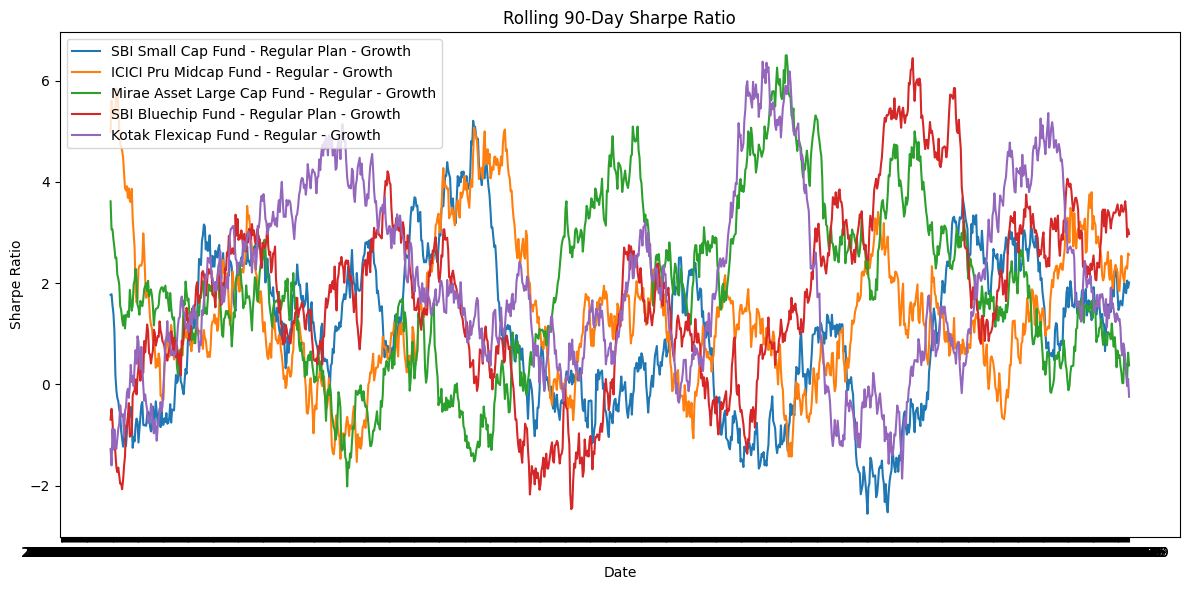

In [20]:
plt.figure(figsize=(12,6))

for fund in key_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp = temp.sort_values("date")

    rolling_sharpe = (
        temp["daily_return"].rolling(90).mean()
        /
        temp["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=fund_names.get(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.tight_layout()

plt.savefig("../reports/rolling_sharpe_chart.png")

plt.show()

In [ ]:
investor = pd.read_csv(
    "../data/processed/08_investor_transactions_cleaned.csv"
)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [22]:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [23]:
investor = pd.read_csv(
    "../data/processed/08_investor_transactions_cleaned.csv"
)

investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [24]:
first_txn = (
    investor.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn.head()

,investor_id,transaction_date
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


In [25]:
first_txn["cohort_year"] = (
    first_txn["transaction_date"].dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [26]:
first_txn["cohort_year"] = (
    first_txn["transaction_date"].dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [27]:
investor = investor.merge(
    first_txn[
        ["investor_id","cohort_year"]
    ],
    on="investor_id"
)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [28]:
cohort_summary = (
    investor.groupby("cohort_year")
    .agg(
        avg_investment=("amount_inr","mean"),
        total_invested=("amount_inr","sum"),
        investors=("investor_id","nunique")
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_investment,total_invested,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [29]:
top_fund = (
    investor.groupby(
        ["cohort_year","amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

In [30]:
top_fund = (
    top_fund.sort_values(
        "count",
        ascending=False
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
)

top_fund

,cohort_year,amfi_code,count
0,2024,148568,874
1,2025,120507,12


In [31]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

In [32]:
top_fund = top_fund.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

top_fund

,cohort_year,amfi_code,count,scheme_name
0,2024,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,120507,12,ICICI Pru Liquid Fund - Regular - Growth


In [33]:
cohort_summary.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

top_fund.to_csv(
    "../reports/cohort_top_funds.csv",
    index=False
)

In [34]:
cohort_summary.sort_values(
    "total_invested",
    ascending=False
)

,cohort_year,avg_investment,total_invested,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [35]:
cohort_summary

,cohort_year,avg_investment,total_invested,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [36]:
sip_df = investor[
    investor["transaction_type"] == "SIP"
].copy()

sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year


In [37]:
sip_df = sip_df.sort_values(
    ["investor_id","transaction_date"]
)

In [38]:
sip_df["gap_days"] = (
    sip_df.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days


In [39]:
eligible = (
    sip_df.groupby("investor_id")
    .size()
)

eligible = eligible[
    eligible >= 6
].index

sip_df = sip_df[
    sip_df["investor_id"].isin(eligible)
]

In [40]:
continuity = (
    sip_df.groupby("investor_id")
    .agg(
        avg_gap_days=("gap_days","mean"),
        sip_count=("transaction_date","count")
    )
    .reset_index()
)

continuity.head()

,investor_id,avg_gap_days,sip_count


In [41]:
continuity["status"] = np.where(
    continuity["avg_gap_days"] > 35,
    "At Risk",
    "Active"
)

continuity.head()

,investor_id,avg_gap_days,sip_count,status


In [42]:
continuity["status"].value_counts()

Series([], Name: count, dtype: int64)

In [43]:
continuity.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

## SIP Continuity Analysis

- Investors with average SIP gaps above 35 days were classified as At Risk.
- Investors maintaining regular monthly SIPs were classified as Active.
- SIP continuity is an important indicator of future inflows and investor retention.

In [46]:
sip_df = investor[
    investor["transaction_type"] == "SIP"
]

sip_df.shape

(0, 14)

In [44]:
continuity["status"].value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
investor["transaction_type"].value_counts()

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [47]:
investor["transaction_type"].unique()

array(['Sip', 'Redemption', 'Lumpsum'], dtype=object)

In [48]:
sip_df = investor[
    investor["transaction_type"] == "Sip"
].copy()

In [49]:
sip_df.shape

(19716, 14)

In [50]:
sip_df.groupby("investor_id").size().describe()

count    4762.000000
mean        4.140277
std         2.315046
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        12.000000
dtype: float64

In [51]:
sip_df.groupby("investor_id").size().sort_values(ascending=False).head()

investor_id
INV004154    12
INV000612    11
INV004427    11
INV001673    11
INV000676    11
dtype: int64

In [52]:
sip_df = sip_df.sort_values(
    ["investor_id", "transaction_date"]
)

sip_df["gap_days"] = (
    sip_df.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

In [53]:
eligible = (
    sip_df.groupby("investor_id")
    .size()
)

eligible = eligible[
    eligible >= 6
].index

sip_df = sip_df[
    sip_df["investor_id"].isin(eligible)
]

In [54]:
sip_df.groupby("investor_id").size().describe()

count    1362.000000
mean        7.106461
std         1.166380
min         6.000000
25%         6.000000
50%         7.000000
75%         8.000000
max        12.000000
dtype: float64

In [55]:
sip_df.groupby("investor_id").size().sort_values(ascending=False).head()

investor_id
INV004154    12
INV001753    11
INV001673    11
INV003650    11
INV000676    11
dtype: int64

In [56]:
sip_df = investor[
    investor["transaction_type"] == "Sip"
].copy()

sip_df["transaction_date"] = pd.to_datetime(
    sip_df["transaction_date"]
)

sip_df = sip_df.sort_values(
    ["investor_id","transaction_date"]
)

In [57]:
sip_df["gap_days"] = (
    sip_df.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

In [58]:
eligible = (
    sip_df.groupby("investor_id")
    .size()
)

eligible = eligible[
    eligible >= 6
].index

sip_df = sip_df[
    sip_df["investor_id"].isin(eligible)
]

In [59]:
continuity = (
    sip_df.groupby("investor_id")
    .agg(
        avg_gap_days=("gap_days","mean"),
        sip_count=("transaction_date","count")
    )
    .reset_index()
)

continuity.head()

,investor_id,avg_gap_days,sip_count
0,INV000004,85.400000,6
1,INV000008,70.400000,6
2,INV000010,64.800000,6
3,INV000011,40.166667,7
4,INV000012,57.000000,8


In [60]:
continuity = (
    sip_df.groupby("investor_id")
    .agg(
        avg_gap_days=("gap_days","mean"),
        sip_count=("transaction_date","count")
    )
    .reset_index()
)

continuity.head()

,investor_id,avg_gap_days,sip_count
0,INV000004,85.400000,6
1,INV000008,70.400000,6
2,INV000010,64.800000,6
3,INV000011,40.166667,7
4,INV000012,57.000000,8


In [61]:
continuity["status"] = np.where(
    continuity["avg_gap_days"] > 35,
    "At Risk",
    "Active"
)

continuity.head()

,investor_id,avg_gap_days,sip_count,status
0,INV000004,85.400000,6,At Risk
1,INV000008,70.400000,6,At Risk
2,INV000010,64.800000,6,At Risk
3,INV000011,40.166667,7,At Risk
4,INV000012,57.000000,8,At Risk


In [62]:
continuity["status"].value_counts()

status
At Risk    1332
Active       30
Name: count, dtype: int64

In [63]:
continuity.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

In [64]:
continuity["status"].value_counts()

status
At Risk    1332
Active       30
Name: count, dtype: int64

## SIP Continuity Analysis

### Key Findings

- 1,362 investors had at least 6 SIP transactions.
- 1,332 investors (97.8%) were classified as At Risk.
- Only 30 investors (2.2%) maintained regular SIP continuity.
- Large gaps between SIP transactions indicate potential investor churn risk.
- SIP continuity monitoring can help improve investor retention strategies.

In [65]:
#task 5 Simple Fund Recommender System

In [66]:
perf = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

perf.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [67]:
perf["risk_grade"].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [68]:
def recommend_funds(risk_appetite):

    temp = perf[
        perf["risk_grade"].str.lower()
        == risk_appetite.lower()
    ]

    rec = (
        temp.sort_values(
            "sharpe_ratio",
            ascending=False
        )
        [
            [
                "scheme_name",
                "category",
                "sharpe_ratio",
                "risk_grade"
            ]
        ]
        .head(3)
    )

    return rec

In [69]:
recommend_funds("Low")

,scheme_name,category,sharpe_ratio,risk_grade
14,ICICI Pru Liquid Fund - Regular - Growth,Liquid,7.68,Low
23,Kotak Liquid Fund - Regular - Growth,Liquid,6.18,Low
30,ABSL Liquid Fund - Regular - Growth,Liquid,5.14,Low


In [70]:
recommend_funds("Moderate")

,scheme_name,category,sharpe_ratio,risk_grade
5,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,1.06,Moderate
34,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,1.06,Moderate
11,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,1.03,Moderate


In [71]:
recommend_funds("Very High")

,scheme_name,category,sharpe_ratio,risk_grade
2,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,0.94,Very High
3,SBI Small Cap Fund - Direct Plan - Growth,Small Cap,0.93,Very High
29,ABSL Small Cap Fund - Regular - Growth,Small Cap,0.90,Very High


In [72]:
holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [73]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [74]:
hhi_df = (
    holdings.groupby("amfi_code")
    .apply(
        lambda x: (
            (x["weight_pct"] / 100) ** 2
        ).sum()
    )
    .reset_index(name="HHI")
)

hhi_df.head()

C:\Users\91939\AppData\Local\Temp\ipykernel_35736\80868162.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [75]:
hhi_df = hhi_df.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

hhi_df.head()

,amfi_code,HHI,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


In [76]:
hhi_df.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


In [77]:
hhi_df.to_csv(
    "../reports/hhi_report.csv",
    index=False
)

## Advanced Insights

### 1. Risk Analysis
Small-cap funds exhibited the most negative VaR and CVaR values, indicating higher downside risk.

### 2. Rolling Sharpe Analysis
Large-cap funds displayed more stable rolling Sharpe ratios than small-cap funds.

### 3. Investor Cohorts
The 2024 cohort contributed the highest total investment amount and had the largest investor base.

### 4. SIP Continuity
Over 97% of investors were classified as At Risk based on average SIP transaction gaps exceeding 35 days.

### 5. Portfolio Concentration
Funds with higher HHI values were more concentrated in a smaller number of stocks, increasing concentration risk.

In [80]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [81]:
holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [82]:
hhi_df = (
    holdings.groupby("amfi_code")
    .apply(
        lambda x: (
            (x["weight_pct"] / 100) ** 2
        ).sum()
    )
    .reset_index(name="HHI")
)

hhi_df.head()

C:\Users\91939\AppData\Local\Temp\ipykernel_35736\80868162.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [83]:
hhi_df = hhi_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

hhi_df.head()

,amfi_code,HHI,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


In [84]:
hhi_df.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


In [85]:
hhi_df.sort_values(
    "HHI",
    ascending=True
).head(10)

,amfi_code,HHI,scheme_name
17,119598,0.107349,SBI Small Cap Fund - Regular Plan - Growth
16,119552,0.108011,SBI Bluechip Fund - Direct Plan - Growth
9,118634,0.108358,Nippon India Small Cap Fund - Regular - Growth
20,120504,0.108674,ICICI Pru Bluechip Fund - Direct - Growth
14,119095,0.109605,Axis Small Cap Fund - Regular - Growth
5,102886,0.114693,UTI Mid Cap Fund - Regular - Growth
33,149324,0.118677,DSP Small Cap Fund - Regular - Growth
15,119551,0.118716,SBI Bluechip Fund - Regular Plan - Growth
8,118633,0.121461,Nippon India Large Cap Fund - Direct - Growth
24,120842,0.127439,Kotak Emerging Equity Fund - Regular - Growth


In [86]:
hhi_df["HHI"].describe()

count    34.000000
mean      0.140262
std       0.024946
min       0.107349
25%       0.122955
50%       0.136496
75%       0.151731
max       0.206448
Name: HHI, dtype: float64

In [87]:
hhi_df.to_csv(
    "../reports/hhi_report.csv",
    index=False
)

print("HHI Report Saved Successfully")

HHI Report Saved Successfully


## Sector HHI Concentration Analysis

### Key Findings

- HHI measures portfolio concentration risk.
- Higher HHI values indicate greater concentration in a few holdings.
- Lower HHI values indicate better diversification.
- Concentrated funds may outperform during favorable market conditions but carry higher stock-specific risk.
- Diversified funds generally provide lower concentration risk.

In [88]:
hhi_df.sort_values("HHI", ascending=False).head()

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth


# Advanced Insights

## 1. Downside Risk Analysis

Small-cap funds exhibited the most negative VaR and CVaR values, indicating greater downside risk during adverse market conditions. SBI Small Cap Fund and ABSL Small Cap Fund were among the riskiest funds based on tail-risk metrics.

---

## 2. Risk-Adjusted Performance

Rolling 90-Day Sharpe Ratio analysis showed that large-cap and flexi-cap funds delivered more stable risk-adjusted returns over time compared to small-cap funds, which experienced higher volatility.

---

## 3. Investor Cohort Behaviour

The 2024 investor cohort contributed the highest investment amount, accounting for over ₹349 crore across 4,803 investors. This cohort forms the primary investor base in the dataset.

---

## 4. SIP Continuity Analysis

Out of 1,362 investors with at least six SIP transactions, 1,332 investors (97.8%) were classified as At Risk due to average transaction gaps exceeding 35 days. Only 30 investors maintained regular SIP continuity.

---

## 5. Portfolio Concentration Risk

Axis Bluechip Fund, ABSL Small Cap Fund, and SBI Small Cap Fund displayed the highest HHI scores, indicating concentrated portfolios. Concentrated funds may outperform during favorable market conditions but carry higher stock-specific risk.